In [1]:
import sys
sys.path.append("../../src")

from common_imports import *
from collections import Counter

In [ ]:
from itertools import combinations
from collections import Counter
import mpmath as mp
import thermal_equilibrium as therm


mp.mp.dps = 100
mp.mp.maxterms = 100000# number of hypergeometric terms before giving up
################################################

In [3]:

import mpmath as mp
from mpmath import pcfd

def u_tilde(tau, q, tf):
    """Eq. 7.2.87"""
    a = 1 + mp.cos(q)
    b = mp.sin(q)

    rot = mp.e**(-1j * 3 * mp.pi / 4)
    rot_inv = mp.e**(1j * 3 * mp.pi / 4)
    decay = mp.e**(-mp.pi * b * b * tau / 4)
    prefactor = rot * b * mp.sqrt(tau) * decay
    argument = rot_inv * 2 * (tf - a * tau) / mp.sqrt(tau)
    nu = 1j * b * b * tau - 1

    with mp.workdps(mp.mp.dps + 20):
        return prefactor * mp.pcfd(nu, argument)

def v_tilde(tau, q, t):
    """Eq. 7.2.88"""
    a = 1 + mp.cos(q)
    b = mp.sin(q)

    rot = mp.e**(-1j * 3 * mp.pi / 4)
    rot_inv = mp.e**(1j * 3 * mp.pi / 4)
    decay = mp.e**(-mp.pi * b * b * tau / 4)
    prefactor = -decay
    argument = rot_inv * 2 * (t - a * tau) / mp.sqrt(tau)
    nu = 1j * b * b * tau

    with mp.workdps(mp.mp.dps + 20):
        return prefactor * mp.pcfd(nu, argument)





def g(t,tau):
    return -t/tau + 1


In [4]:

################################################
#           FULL SYSTEM SOLUTIONS
################################################
def k_vals(L):
    """Generates k values >0"""
    x=(2 * np.arange(-L//2, L//2) + 1) * np.pi / (L)
    return x[x>0]


# def state(L,tau,t):
#     """Generates state as [us, vs, k]"""
#     #Generate momentum values
#     k = k_vals(L)
#     us = np.array([u_tilde(tau,q,t) for q in k])
#     vs = np.array([v_tilde(tau,q,t) for q in k])
#     return [us,vs,k]


def state(L, tau, t):
    k = k_vals(L)
    # directly convert mp.mpc to np.complex128 during comprehension
    us = np.array([complex(u_tilde(tau, q, t)) for q in k], dtype=np.complex128)
    vs = np.array([complex(v_tilde(tau, q, t)) for q in k], dtype=np.complex128)
    k  = np.array(k, dtype=np.float64)
    return [us, vs, k]
def G(r,state):
    """r = integer
    state = [us, vs, k]
    calculates {bi,aj} correlation of r=j-i
    """
    u = state[0]
    v = state[1]
    k = state[2]
    #Equation 7.2.26a
    Gr = 2*cos(k*r)*(np.abs(u)**2-np.abs(v)**2)-2j*sin(k*r)*(np.conj(u)*v-np.conj(v)*u)
    return -np.mean(Gr)/2

def D(n,state):
    """Strange Convention, n = r-1"""
    r = n+1
    return G(r,state)

In [5]:
def nk(k,T):
    g0 = 100
    e = 2*sqrt( (g0-cos(k))**2+sin(k)**2)
    return 1/(1+exp(e/T))

In [6]:
def G_th(r,state,T):
    """r = integer
    state = [us, vs, k]
    calculates {bi,aj} correlation of r=j-i
    """
    u = state[0]
    v = state[1]
    k = state[2]
    nks = nk(k,T)
    #Equation 7.2.26a
    Gr = 2*cos(k*r)*(np.abs(u)**2-np.abs(v)**2)-2j*sin(k*r)*(np.conj(u)*v-np.conj(v)*u)
    return -np.mean(Gr*(1-2*nks))/2
def D(n,state,T):
    """Strange Convention, n = r-1"""
    r = n+1
    return G_th(r,state,T)
def sigma_general(indices,state,T):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = D(Nd,state,T)
    return np.linalg.det(C)

################################################
#           PPROJECTORS
################################################
def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,state,T):
    even = True
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(sqrt(np.abs(sigma_general(indices,U,k)))*degen)
        else:
            dat.append(sigma_general(indices,state,T)*degen)
    #Manually add the 1 
    dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n




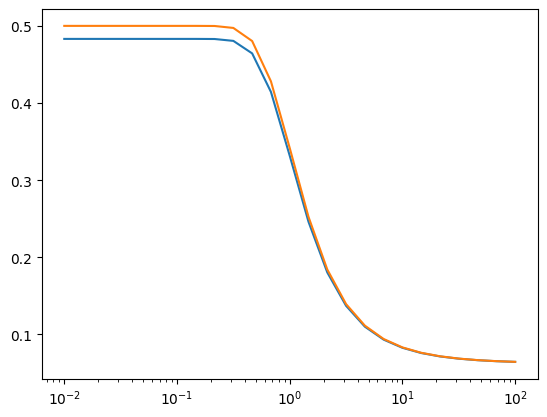

In [16]:
tau = 100
states = state(256,tau,tau)
T= np.logspace(-2,2,25)
G1 = [P_n(4,states,Ti*100) for Ti in T]
plot(T,G1)
G2 = [therm.P_n(4,256,0,Ti ) for Ti in T]
plot(T,G2)
xscale("log")

In [ ]:
taus = np.logspace(-2,3,100)
states = [state(256,tau,tau) for tau in taus]




/tmp/ipykernel_11462/3014266735.py:4: RuntimeWarning: overflow encountered in exp
  return 1/(1+exp(e/T))


[]

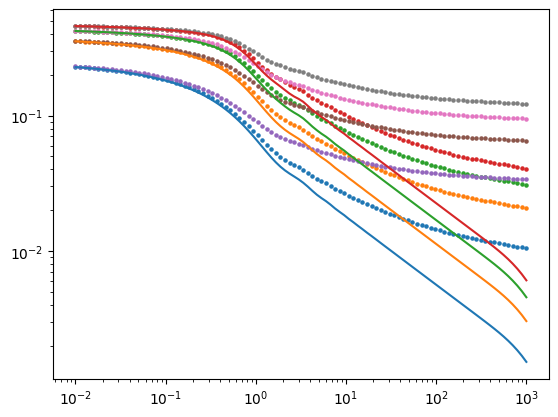

In [38]:
Ts= np.logspace(-2,2,25)
ns = np.arange(2,6)

T = 0.001
for n in ns:
    G = array([P_n(n,s,T) for s in states])
    plot(taus,1/2-G)
xscale("log")
T = 50
for n in ns:
    G = array([P_n(n,s,T) for s in states])
    scatter(taus,1/2-G,s=5)

T = 75
for n in ns:
    G = array([P_n(n,s,T) for s in states])
    scatter(taus,1/2-G,s=5)
xscale("log")
loglog()


In [69]:
def G_th2_real(r, state, T):
    """
    r = j-i
    state = [u, v, k] with k assumed to be k>0 only (paired modes)
    returns real <B_i A_j>
    """
    u, v, k = state
    nks = nk(k, T)

    Nk = np.abs(v)**2 + (np.abs(u)**2 - np.abs(v)**2) * nks
    Fk = u * np.conj(v) * (1 - 2*nks)

    # contribution from +k
    Gp = np.exp(1j*k*r)*(Nk + np.conj(Fk)) + np.exp(-1j*k*r)*(Nk + Fk - 1)

    # add the -k partner (this is what makes it real)
    G = Gp + np.conj(Gp)

    return np.mean(G).real/2


In [72]:
G_th2_real(0,states[0],0)

/tmp/ipykernel_11462/3014266735.py:4: RuntimeWarning: divide by zero encountered in divide
  return 1/(1+exp(e/T))


np.float64(1.0962653604430825)

/tmp/ipykernel_11462/195403782.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  G[i, j] = P_n(n, state, Ti*100)


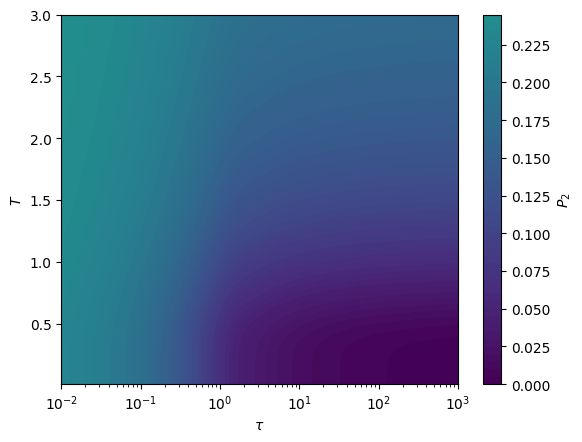

In [106]:
taus = np.array(taus)
Ts   = np.linspace(0.01,3,100)

G = np.zeros((len(Ts), len(states)))
n=2
for i, Ti in enumerate(Ts):
    for j, state in enumerate(states):
        G[i, j] = P_n(n, state, Ti*100)
plt.figure()
plt.contourf(taus, Ts, 1/2-G, levels=50,vmin=0,vmax=.5)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$T$")
plt.colorbar(label=fr"$P_{n}$")
plt.show()

/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/kristian/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


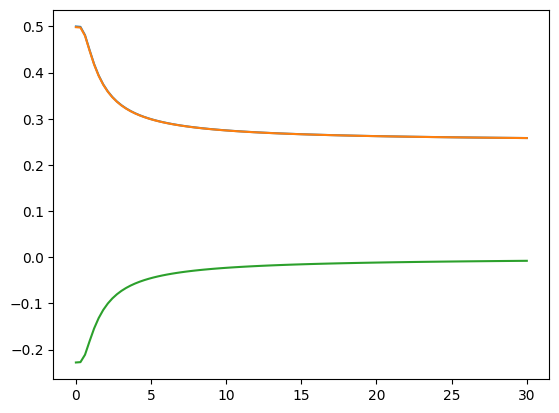

In [135]:
#X = array([therm.P_n(10,256,0,Ti)] for Ti in Ts)
X = np.array([therm.P_n(2, 256, 0, Ti) for Ti in Ts])  # shape (len(Ts),)
G_sub = G - X[:, None]

plot(Ts,X)
plot(Ts,G[:,-1])
plot(Ts,G_sub[:,0])

100%|██████████| 100/100 [00:00<00:00, 616.52it/s]


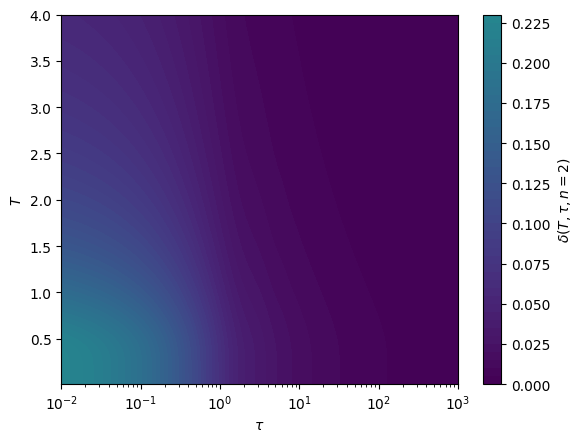

In [151]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

taus = np.array(taus)
Ts   = np.linspace(0.01,4,100)
n    = 2
X = np.array([therm.P_n(n, 256, 0, Ti) for Ti in Ts])  # shape (len(Ts),)

def compute_row(Ti):
    return np.array([P_n(n, state, Ti*100) for state in states])

# run in parallel over T
G = np.vstack(
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_row)(Ti) for Ti in tqdm(Ts)
    )
)
plt.figure()
G_sub = G - X[:, None]
plt.contourf(taus, Ts, np.abs(G_sub), levels=50,vmin=0,vmax=.5)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$T$")
plt.colorbar(label=fr"$\delta(T,\tau,n={n})$")
plt.show()

100%|██████████| 100/100 [00:01<00:00, 73.80it/s]


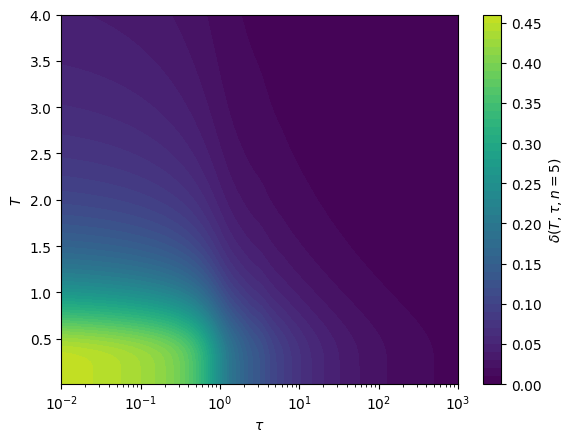

In [152]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

taus = np.array(taus)
Ts   = np.linspace(0.01,4,100)
n    = 5
X = np.array([therm.P_n(n, 256, 0, Ti) for Ti in Ts])  # shape (len(Ts),)

def compute_row(Ti):
    return np.array([P_n(n, state, Ti*100) for state in states])

# run in parallel over T
G = np.vstack(
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_row)(Ti) for Ti in tqdm(Ts)
    )
)
plt.figure()
G_sub = G - X[:, None]
plt.contourf(taus, Ts, np.abs(G_sub), levels=50,vmin=0,vmax=.5)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$T$")
plt.colorbar(label=fr"$\delta(T,\tau,n={n})$")
plt.show()

100%|██████████| 100/100 [02:19<00:00,  1.39s/it]


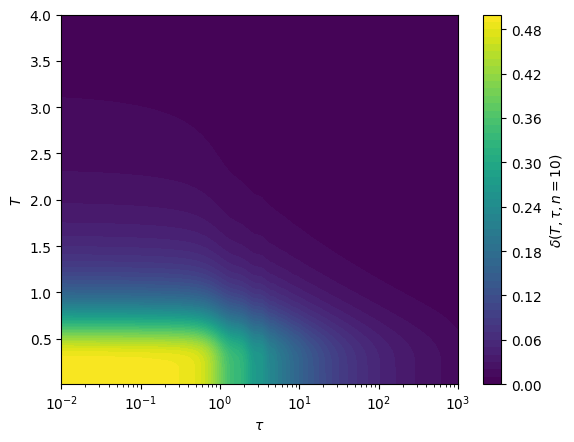

In [153]:
from joblib import Parallel, delayed
import numpy as np
from tqdm import tqdm

taus = np.array(taus)
Ts   = np.linspace(0.01,4,100)
n    = 10
X = np.array([therm.P_n(n, 256, 0, Ti) for Ti in Ts])  # shape (len(Ts),)

def compute_row(Ti):
    return np.array([P_n(n, state, Ti*100) for state in states])

# run in parallel over T
G = np.vstack(
    Parallel(n_jobs=-1, backend="loky")(
        delayed(compute_row)(Ti) for Ti in tqdm(Ts)
    )
)
plt.figure()
G_sub = G - X[:, None]
plt.contourf(taus, Ts, np.abs(G_sub), levels=50,vmin=0,vmax=.5)
plt.xscale("log")
#plt.yscale("log")
plt.xlabel(r"$\tau$")
plt.ylabel(r"$T$")
plt.colorbar(label=fr"$\delta(T,\tau,n={n})$")
plt.show()

/tmp/ipykernel_11462/3014266735.py:4: RuntimeWarning: divide by zero encountered in divide
  return 1/(1+exp(e/T))


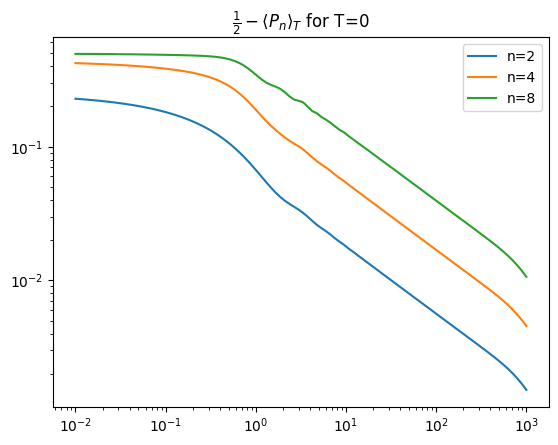

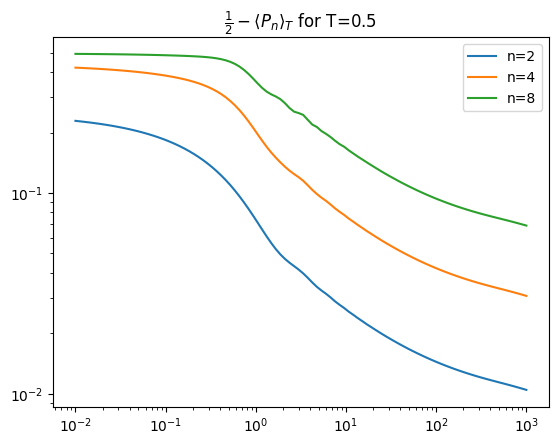

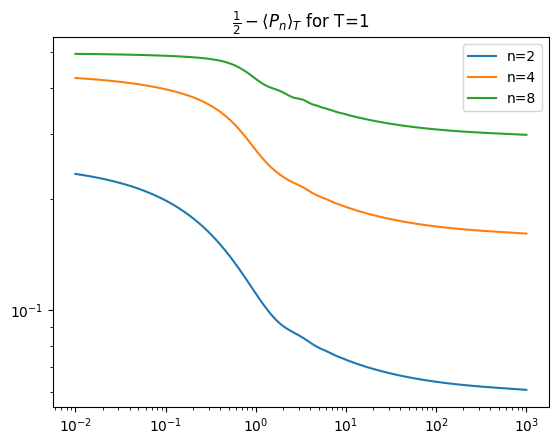

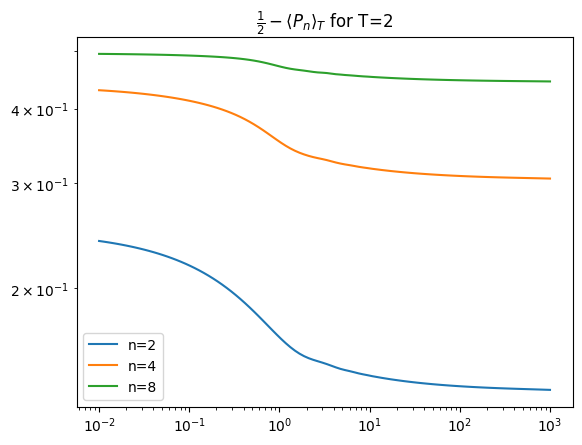

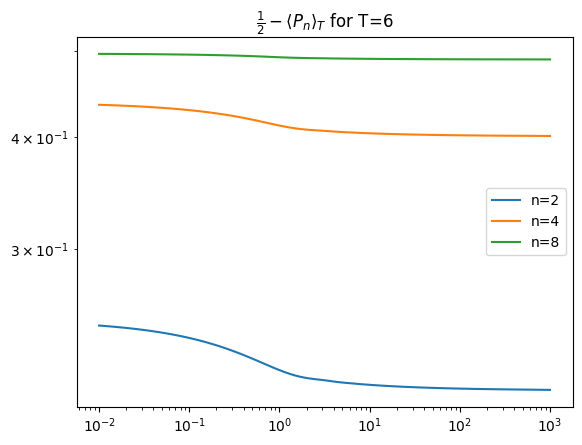

In [202]:
ns = [2,4,8]
Ts = [0,.5,1,2,6]

for T in Ts:
    for n in ns:

        X = therm.P_n(n, 256, 0, T)  # shape (len(Ts),)
        dat = array([P_n(n,s,T*100) for s in states])
        plot(taus,(1/2-np.abs(dat)),label=f"n={n}")
    xscale("log")
    yscale("log")
    title(r"$\frac{1}{2}-\langle P_n \rangle_T$"+f" for T={T}")
    legend()
    show()


/tmp/ipykernel_11462/3014266735.py:4: RuntimeWarning: divide by zero encountered in divide
  return 1/(1+exp(e/T))


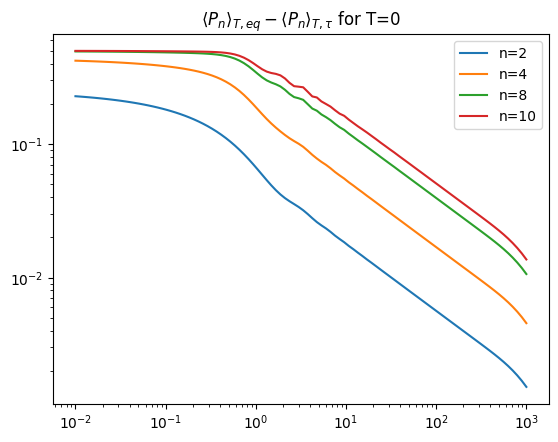

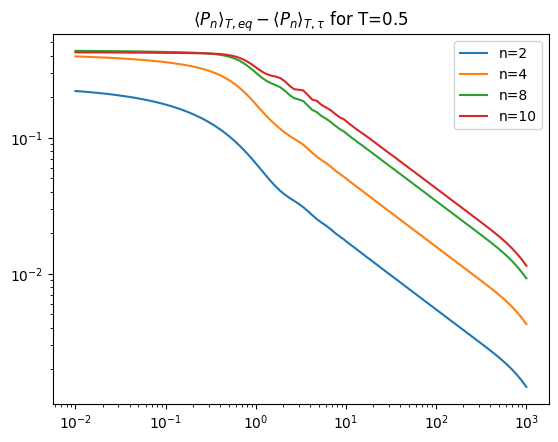

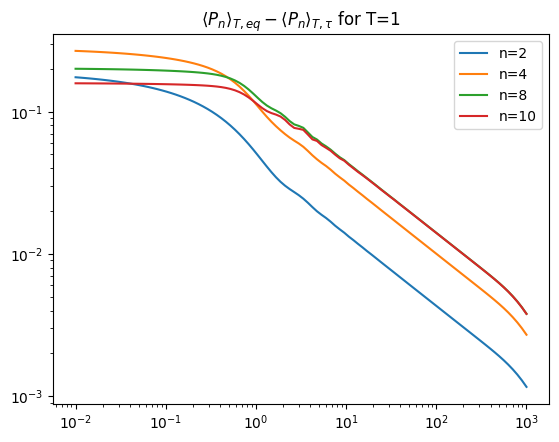

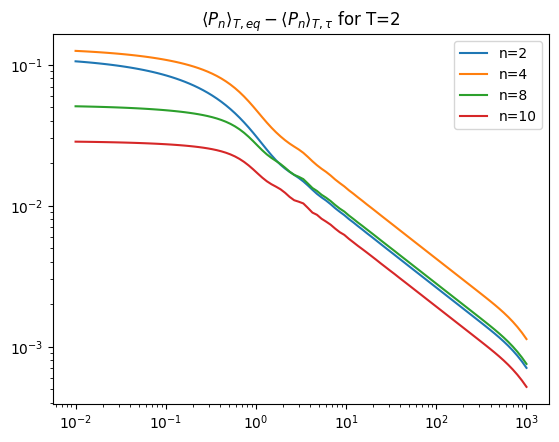

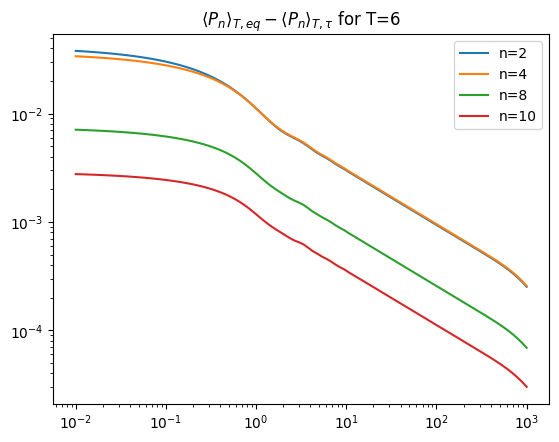

In [205]:
ns = [2,4,8,10]
Ts = [0,.5,1,2,6]

for T in Ts:
    for n in ns:

        X = therm.P_n(n, 256, 0, T)  # shape (len(Ts),)
        dat = array([P_n(n,s,T*100) for s in states])
        plot(taus,(X-np.abs(dat)),label=f"n={n}")
    xscale("log")
    yscale("log")
    title(r"$\langle P_n \rangle_{T,eq}-\langle P_n \rangle_{T,\tau}$"+f" for T={T}")
    legend()
    show()


/tmp/ipykernel_11462/3014266735.py:4: RuntimeWarning: divide by zero encountered in divide
  return 1/(1+exp(e/T))


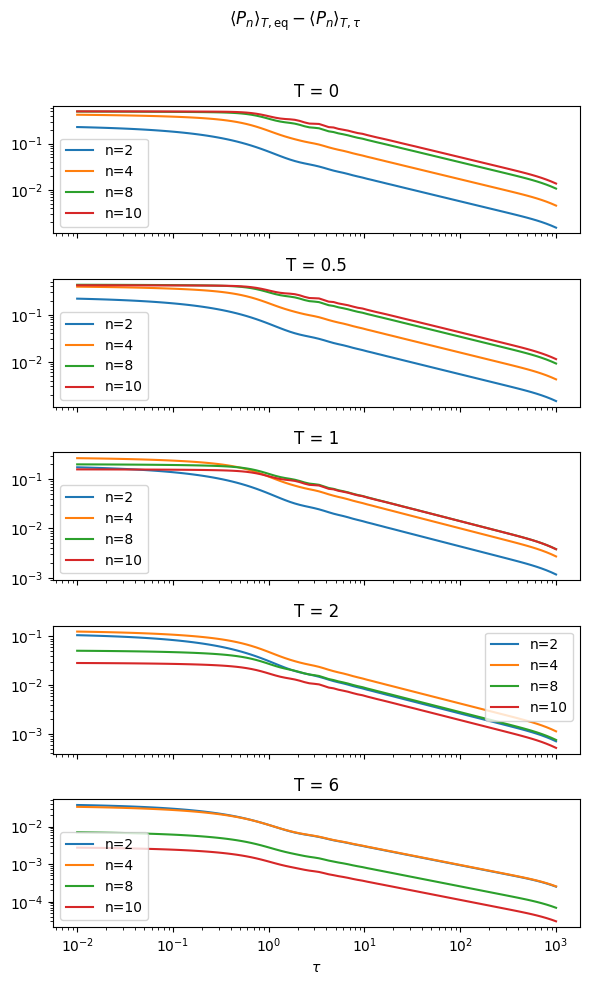

In [206]:
ns = [2, 4, 8, 10]
Ts = [0, .5, 1, 2, 6]

fig, axes = plt.subplots(len(Ts), 1, figsize=(6, 10), sharex=True)

for ax, T in zip(axes, Ts):
    for n in ns:
        X = therm.P_n(n, 256, 0, T)
        dat = np.array([P_n(n, s, T*100) for s in states])
        ax.plot(taus, X - np.abs(dat), label=f"n={n}")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title(f"T = {T}")
    ax.legend()

fig.suptitle(r"$\langle P_n \rangle_{T,\mathrm{eq}}-\langle P_n \rangle_{T,\tau}$", y=0.98)
axes[-1].set_xlabel(r"$\tau$")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
